# 01 · 미분으로 학습시키기

**이번 질문:** 출력의 오차를 알 때, 가중치와 편향을 어느 방향으로 얼마나 바꾸어야 할까요?

[00번](00_math_to_numpy.ipynb)에서는 $Z=XW+b$를 직접 계산했습니다.
이번에는 **목표를 손실로 표현하기 → 미분 → 역전파 → 파라미터 갱신**을 한 문제에서 연결합니다.
수학에서 계산한 기울기를 수치미분과 대조하고, 실제 학습 결과를 다른 방법으로 구한 해와 비교합니다.

각 절은 완성된 작은 예제를 먼저 보여드립니다. 출력값이나 변화 방향을 예상한 뒤 실행하고,
마지막 변형 문제에서 직접 쓴 함수를 검산해 보세요.

[전체 학습 경로](../../docs/CURRICULUM.md) · [그림 보조 코드](../../src/utils/gradient_plots.py)

In [1]:
import sys
from pathlib import Path

project_root = next(
    p for p in (Path.cwd(), *Path.cwd().parents)
    if (p / "src" / "utils" / "plotting.py").is_file()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
from src.utils import setup_plots
setup_plots()
np.set_printoptions(precision=4, suppress=True)
print("NumPy", np.__version__, "· 준비 완료")

from src import check_function, rel_error
from src.utils import plot_gradcheck
from src.utils.gradient_plots import (
    plot_derivative, plot_difference_errors, plot_loss_surface,
    plot_fit_snapshots, plot_learning_curves,
)

NumPy 2.3.5 · 준비 완료


## 1. 원하는 결과를 손실로 만듭니다

입력 $x$에 대해 숫자 $y$를 예측하는 **회귀(regression)** 문제를 풀겠습니다.
예측값은 $\hat y=xw+b$입니다. 모자를 쓴 $\hat y$는 모델의 예측, $y$는 관측된 정답을 뜻합니다.

예측과 정답의 차이 $r=\hat y-y$를 **잔차(residual)**라고 합니다.
부호가 다른 잔차가 서로 상쇄되지 않도록 제곱하고, 모든 출력값에 대해 평균을 내겠습니다.
큰 잔차에 더 큰 값을 주는 매끄러운 목적을 선택한 것입니다.

$$J=\frac1{2M}\sum_{j=1}^{M}(\hat y_j-y_j)^2.$$

일반적인 MSE(mean squared error)에 $1/2$를 곱한 정의를 사용합니다.
이 상수는 최솟값의 위치를 유지하고, 미분할 때 제곱에서 나오는 2와 약분됩니다.
$M$은 평균에 포함된 **스칼라 출력값의 총 개수**입니다. 예측이 `(N, K)`이면 $M=NK$입니다.

이 노트북에서는 이 목적을 선택한 뒤 정확히 최적화하는 데 집중합니다.
다음 단원에서는 가우스 오차 가정과 우도로부터 같은 목적을 다시 유도합니다.

In [2]:
def mse_forward(prediction, target):
    if prediction.shape != target.shape or prediction.size == 0:
        raise ValueError("prediction과 target은 같은 모양의 비어 있지 않은 배열로 둡니다.")
    residual = prediction - target
    return 0.5 * np.mean(residual ** 2), residual

In [3]:
prediction_example = np.array([[0.0], [2.0], [4.0]])
target_example = np.array([[1.0], [1.0], [3.0]])
loss_example, residual_example = mse_forward(prediction_example, target_example)
np.testing.assert_array_equal(residual_example, [[-1.0], [1.0], [1.0]])
np.testing.assert_allclose(loss_example, 0.5)
print("잔차", residual_example.ravel(), "· 손실", loss_example)

잔차 [-1.  1.  1.] · 손실 0.5


손실은 모델 전체를 평가하는 **스칼라 하나**입니다.
그 값이 작아지는 방향으로 파라미터를 움직이는 것이 여기서의 학습 목표입니다.

## 2. 미분은 작은 변화에 대한 반응입니다

함수 $f(w)$에 대해 입력을 $h$만큼 늘렸을 때 평균 변화율은

$$\frac{f(w+h)-f(w)}h$$

입니다. $h$를 0에 가깝게 보냈을 때의 극한을 도함수 $f'(w)$라고 합니다.
작은 $\Delta w$에 대해서는 $f(w+\Delta w)\approx f(w)+f'(w)\Delta w$로 예상할 수 있습니다.

예를 들어 $f(w)=w^3$이면

$$\frac{(w+h)^3-w^3}{h}=3w^2+3wh+h^2\quad\longrightarrow\quad f'(w)=3w^2.$$

$w=1$에서 도함수는 3입니다. 아래에서 함수와 그 점의 접선을 함께 보겠습니다.

In [4]:
def cubic(w):
    return w ** 3


def cubic_derivative(w):
    return 3 * w ** 2

In [5]:
w0, h = 1.0, 0.3
grid = np.linspace(0.3, 1.7, 150)
function_values = cubic(grid)
tangent_values = cubic(w0) + cubic_derivative(w0) * (grid - w0)
secant_points = np.array([w0, w0 + h])
secant_values = cubic(secant_points)
np.testing.assert_allclose(cubic_derivative(w0), 3.0)
print("도함수", cubic_derivative(w0), "· 폭 0.3의 평균 변화율", (cubic(w0 + h) - cubic(w0)) / h)

도함수 3.0 · 폭 0.3의 평균 변화율 3.99


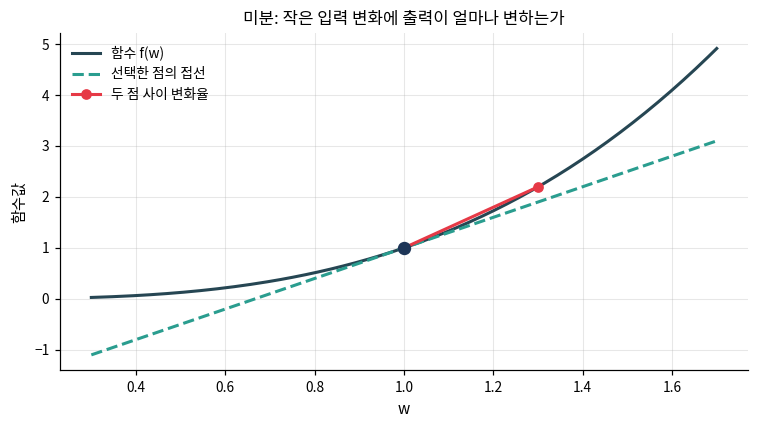

In [6]:
plot_derivative(grid, function_values, tangent_values, w0, cubic(w0), secant_points, secant_values)

두 점의 간격이 작아질수록 평균 변화율은 그 점의 접선 기울기에 가까워집니다.
접선은 해당 점 근처의 변화를 설명합니다. 파라미터를 크게 움직이면 실제 함수의 곡률도 영향을 줍니다.

## 3. 수치미분으로 도함수를 검산합니다

앞의 식을 그대로 계산한 것이 **전진차분**입니다.
좌우를 함께 사용하는 **중심차분**은 다음과 같습니다.

$$f'(w)\approx\frac{f(w+\epsilon)-f(w-\epsilon)}{2\epsilon}.$$

3차식에서 중심차분을 직접 전개하면 $3w^2+\epsilon^2$입니다.
전진차분의 $3w\epsilon$ 항이 사라지므로, 반올림 오차가 작을 때 더 정확합니다.
하지만 매우 작은 $\epsilon$에서는 거의 같은 두 수를 빼는 부동소수점 오차가 영향을 줍니다.

In [7]:
def central_difference(function, value, epsilon=1e-6):
    return (function(value + epsilon) - function(value - epsilon)) / (2 * epsilon)

In [8]:
epsilons = np.logspace(-1, -12, 12)
forward_estimates = np.array([(cubic(w0 + e) - cubic(w0)) / e for e in epsilons])
central_estimates = np.array([central_difference(cubic, w0, e) for e in epsilons])
forward_errors = np.abs(forward_estimates - cubic_derivative(w0))
central_errors = np.abs(central_estimates - cubic_derivative(w0))
np.testing.assert_allclose(central_difference(cubic, w0), 3.0, rtol=1e-8)
for e, estimate in zip(epsilons, central_estimates):
    print(f"epsilon={e:.0e} · 중심차분 {estimate:.10f}")

epsilon=1e-01 · 중심차분 3.0100000000
epsilon=1e-02 · 중심차분 3.0001000000
epsilon=1e-03 · 중심차분 3.0000010000
epsilon=1e-04 · 중심차분 3.0000000100
epsilon=1e-05 · 중심차분 3.0000000001
epsilon=1e-06 · 중심차분 2.9999999999
epsilon=1e-07 · 중심차분 3.0000000001
epsilon=1e-08 · 중심차분 2.9999999929
epsilon=1e-09 · 중심차분 3.0000000817
epsilon=1e-10 · 중심차분 3.0000002482
epsilon=1e-11 · 중심차분 3.0000002482
epsilon=1e-12 · 중심차분 3.0001001683


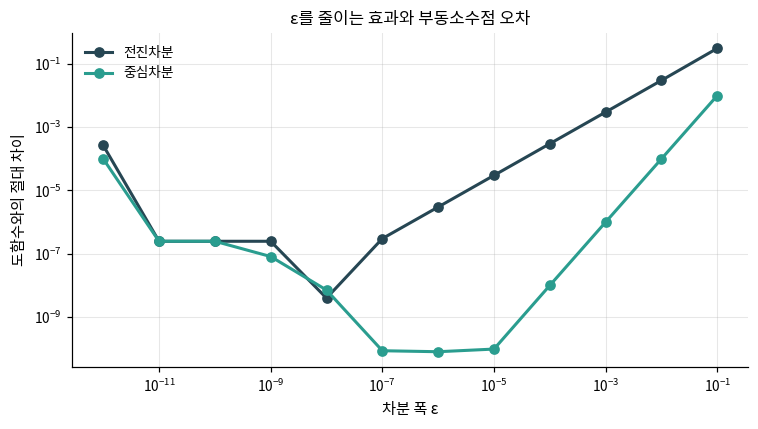

In [9]:
plot_difference_errors(epsilons, forward_errors, central_errors)

수치미분은 유도한 기울기를 점검하는 별도의 계산 방법입니다.
파라미터가 $P$개이면 중심차분에 대략 $2P$번의 함수 평가가 필요하므로,
큰 모델의 매 학습 스텝에는 아래에서 유도할 역전파를 사용합니다.

## 4. 연쇄법칙으로 손실에서 입력까지 거슬러 갑니다

먼저 스칼라 하나로 보겠습니다.

$$w\ \longrightarrow\ z=xw+b\ \longrightarrow\ r=z-y\ \longrightarrow\ J=\tfrac12r^2.$$

각 화살표의 작은 변화율을 곱하면 전체 변화율이 됩니다. 이것이 **연쇄법칙(chain rule)**입니다.

$$\frac{\partial J}{\partial w}
=\frac{\partial J}{\partial r}\frac{\partial r}{\partial z}\frac{\partial z}{\partial w}
=r\cdot1\cdot x.$$

$\partial$는 다른 독립 변수는 고정하고 하나만 바꾸는 **편미분** 표기입니다.
손실에서 출발해 이 계산을 역순으로 수행하는 것이 **역전파(backpropagation)**입니다.

배치와 출력이 여러 개이면 평균에 포함된 모든 값의 개수로 나눕니다.

$$dZ_{nk}:=\frac{\partial J}{\partial Z_{nk}}=\frac{Z_{nk}-Y_{nk}}{NK}.$$

여기서 `dZ`는 미분 기호 자체가 아니라, 각 원소에 대한 편미분을 모은 배열의 이름입니다.

선형 계산 $Z_{nk}=\sum_d X_{nd}W_{dk}+b_k$에서 $W_{dk}$ 하나는 모든 샘플에 쓰입니다.
각 사용처의 기여를 더하면 다음 식이 나옵니다.

$$dW_{dk}=\sum_n X_{nd}\,dZ_{nk},\qquad
 db_k=\sum_n dZ_{nk},\qquad
 dX_{nd}=\sum_k dZ_{nk}\,W_{dk}.$$

| 미분 배열 | 모양 | 배열 연산 |
|---|---|---|
| $dZ$ | `(N, K)` | `(Z - Y) / (N * K)` |
| $dW$ | `(D, K)` | `X.T @ dZ` |
| $db$ | `(K,)` | `dZ.sum(axis=0)` |
| $dX$ | `(N, D)` | `dZ @ W.T` |

$X^\top$는 샘플 축 $n$을 곱하고 더하기 위한 배치입니다.
00번에서 다룬 인덱스 식과 행렬곱의 대응을 다시 사용한 것입니다.

In [10]:
def affine_forward(X, W, b):
    Z = X @ W + b
    return Z, (X, W)


def affine_backward(dZ, cache):
    X, W = cache
    dX = dZ @ W.T
    dW = X.T @ dZ
    db = dZ.sum(axis=0)
    return dX, dW, db


def mse_backward(residual):
    return residual / residual.size

In [11]:
X_small = np.array([[-1.0], [0.0], [1.0]])
Y_small = np.array([[-1.0], [1.0], [3.0]])
W_small, b_small = np.array([[0.0]]), np.array([0.0])
Z_small, affine_cache = affine_forward(X_small, W_small, b_small)
J_small, residual = mse_forward(Z_small, Y_small)
dX_small, dW_small, db_small = affine_backward(mse_backward(residual), affine_cache)
np.testing.assert_allclose(J_small, 11 / 6)
np.testing.assert_allclose(dW_small, [[-4 / 3]])
np.testing.assert_allclose(db_small, [-1.0])
print("예측", Z_small.ravel(), "· 손실", J_small)
print("손계산과 비교: dW", dW_small.ravel(), "db", db_small)

예측 [0. 0. 0.] · 손실 1.8333333333333333
손계산과 비교: dW [-1.3333] db [-1.]


$W$와 $b$에 대한 기울기가 모두 음수입니다. 따라서 두 값을 조금 늘리면 손실이 줄어들 것으로 예상할 수 있습니다.

캐시에는 backward에 필요한 $X$와 $W$를 남겼습니다.
입력 $X$를 학습하지 않는 이 회귀 문제에서도 $dX$를 계산해 두면, 앞에 다른 계산을 이어 붙였을 때 전달할 수 있습니다.

## 5. 모든 기울기를 다른 계산으로 대조합니다

검산에는 작은 입력을 사용하되 **출력이 2개인 경우**도 넣습니다.
출력 개수가 늘었을 때 평균의 분모를 빠뜨리는 실수를 확인하기 위해서입니다.

`check_function`은 입력 배열의 각 원소를 좌우로 조금씩 바꾸어 중심차분을 계산합니다.
여기서는 손실을 $X$, $W$, $b$ 각각의 함수로 보고, 손으로 유도한 기울기와 대조합니다.

아래 콜백의 `dout`은 **검사기가 forward의 출력으로 전달하는 상류 기울기**입니다.
이 forward는 스칼라 손실 $J$를 반환합니다. 검사기는 고정된 스칼라 $u$를 골라
$G=uJ$의 변화율을 중심차분으로 계산하고, `backward`에는 `dout=u`를 전달합니다.
연쇄법칙에 따라 $\partial G/\partial W=u\,\partial J/\partial W$이므로,
콜백도 이미 구한 기울기에 `dout`을 곱해야 같은 값을 비교할 수 있습니다.

앞의 `dZ`는 $\partial J/\partial Z$로 예측 배열과 같은 `(N, K)` 모양이었고,
여기의 `dout`은 $\partial G/\partial J$로 스칼라입니다. 전달받은 변화율을 곱한다는 원리는 같습니다.
검사기의 내부 구현은 [gradcheck.py](../../src/utils/gradcheck.py)의 `check_function`에서 볼 수 있습니다.


In [12]:
def loss_and_gradients(X, W, b, Y):
    Z, cache = affine_forward(X, W, b)
    loss, residual = mse_forward(Z, Y)
    dX, dW, db = affine_backward(mse_backward(residual), cache)
    return loss, {"X": dX, "W": dW, "b": db}


def check_affine_mse(arguments, Y):
    errors = {}
    for name in ("X", "W", "b"):
        def forward(value, name=name):
            current = dict(arguments)
            current[name] = value
            return np.array(loss_and_gradients(**current, Y=Y)[0])

        def backward(dout, value, name=name):
            current = dict(arguments)
            current[name] = value
            return dout * loss_and_gradients(**current, Y=Y)[1][name]

        errors["d" + name] = check_function(
            forward, backward, arguments[name], name="d" + name, verbose=True,
        )
    return errors

In [13]:
rng = np.random.default_rng(7)
check_arguments = {
    "X": rng.normal(size=(4, 3)),
    "W": rng.normal(size=(3, 2)),
    "b": rng.normal(size=(2,)),
}
check_Y = rng.normal(size=(4, 2))
gradient_errors = check_affine_mse(check_arguments, check_Y)
assert max(gradient_errors.values()) < 1e-7

[gradcheck] dX
  ok   dx  rel_err = 1.512e-10
[gradcheck] dW
  ok   dx  rel_err = 1.713e-10
[gradcheck] db
  ok   dx  rel_err = 6.268e-11


<Axes: ylabel='상대오차'>

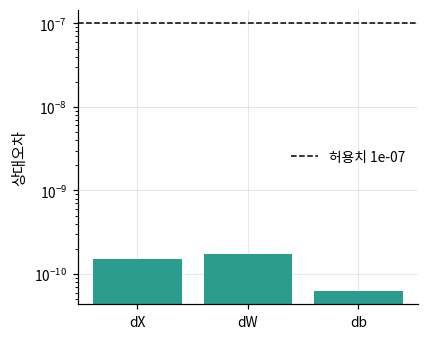

In [14]:
plot_gradcheck(gradient_errors)

### 평균을 두 번 내는 실수를 검산으로 찾습니다

상류의 `dZ`에는 손실의 평균이 이미 반영되어 있습니다.
여기서 `db = dZ.mean(axis=0)`으로 계산하면 샘플 수로 한 번 더 나누게 됩니다.
아래에서는 이 식만 바꾼 기울기를 검사해, 검산이 차이를 잡는지 확인합니다.

In [15]:
def wrong_bias_gradient(dout, bias_value):
    current = dict(check_arguments)
    current["b"] = bias_value
    Z, _ = affine_forward(**current)
    _, residual = mse_forward(Z, check_Y)
    return dout * mse_backward(residual).mean(axis=0)


def bias_objective(bias_value):
    return np.array(loss_and_gradients(check_arguments["X"], check_arguments["W"], bias_value, check_Y)[0])

In [16]:
wrong_error = check_function(bias_objective, wrong_bias_gradient, check_arguments["b"],
                             raise_on_fail=False, name="평균 중복", verbose=True)
assert wrong_error > 1e-3
print("정상 db 오차", gradient_errors["db"], "· 평균을 두 번 낸 db 오차", wrong_error)

[gradcheck] 평균 중복
  FAIL dx  rel_err = 7.500e-01
정상 db 오차 6.268162498977536e-11 · 평균을 두 번 낸 db 오차 0.7500000000017653


## 6. 미분을 파라미터 갱신으로 연결합니다

기울기 $g=\partial J/\partial w$를 알면, 다음처럼 갱신하겠습니다.

$$w_{\mathrm{new}}=w-\alpha g.$$

$\alpha$는 한 번에 얼마나 움직일지 정하는 **학습률(learning rate)**입니다.
작은 변화에 대한 근사에 $\Delta w=-\alpha g$를 넣으면

$$\Delta J\approx g\Delta w=-\alpha g^2\le0$$

가 됩니다. 여러 파라미터에서도 $\Delta J\approx-\alpha\|\nabla J\|^2$입니다.
이 관계가 기울기의 반대 방향으로 움직이는 이유입니다. 큰 스텝의 결과는 실제 손실로 확인합니다.

역전파는 **기울기를 계산**하고, optimizer는 그 값을 사용해 **파라미터를 갱신**합니다.
이번에는 가장 기본적인 전체 배치 경사하강을 직접 씁니다.

In [17]:
learning_rate = 0.1
W_after = W_small - learning_rate * dW_small
b_after = b_small - learning_rate * db_small
Z_after, _ = affine_forward(X_small, W_after, b_after)
J_after, _ = mse_forward(Z_after, Y_small)
assert J_after < J_small
print("W", W_small.ravel(), "→", W_after.ravel())
print("b", b_small, "→", b_after)
print(f"손실 {J_small:.6f} → {J_after:.6f}")

W [0.] → [0.1333]
b [0.] → [0.1]
손실 1.833333 → 1.566481


## 7. 반복하면 실제로 학습되는지 확인합니다

작은 직선 회귀 데이터를 직접 만듭니다.
$y=2x+0.7$에 잡음을 더하고, 초기 예측은 기울기가 반대인 직선에서 시작합니다.

학습 루프는 네 동작입니다.

1. 현재 파라미터로 예측합니다.
2. 정답과 비교해 손실을 계산합니다.
3. 손실에서 시작해 기울기를 계산합니다.
4. 가중치와 편향을 갱신합니다.

매 기록의 손실과 파라미터는 같은 시점의 값입니다. `history`는 세 목록을 담은 딕셔너리입니다.
`history["loss"][0]`, `history["W"][0]`, `history["b"][0]`은 각각 갱신 전 손실·가중치·편향입니다.

In [18]:
def fit_linear(X, Y, W_start, b_start, learning_rate=0.1, steps=200):
    W, b = W_start.copy(), b_start.copy()
    history = {"loss": [], "W": [], "b": []}
    for step in range(steps + 1):
        prediction, cache = affine_forward(X, W, b)
        loss, residual = mse_forward(prediction, Y)
        history["loss"].append(float(loss))
        history["W"].append(W.copy())
        history["b"].append(b.copy())
        if step == steps:
            break
        _, dW, db = affine_backward(mse_backward(residual), cache)
        W -= learning_rate * dW
        b -= learning_rate * db
    return W, b, history

In [19]:
rng_data = np.random.default_rng(12)
X_train = np.linspace(-2.0, 2.0, 40)[:, None]
Y_train = 2.0 * X_train + 0.7 + rng_data.normal(0.0, 0.15, size=X_train.shape)
W_start, b_start = np.array([[-1.5]]), np.array([-1.0])
W_fit, b_fit, history = fit_linear(X_train, Y_train, W_start, b_start)
print(f"학습 전 손실 {history['loss'][0]:.6f} → 200회 뒤 {history['loss'][-1]:.6f}")
print("학습한 가중치", W_fit.ravel(), "편향", b_fit)
assert history["loss"][-1] < history["loss"][0] / 100

학습 전 손실 9.961568 → 200회 뒤 0.008696
학습한 가중치 [1.9842] 편향 [0.6999]


### 독립적인 해로 검산합니다

이 작은 선형 회귀에는 반복 학습과 다른 풀이도 있습니다.
입력에 1로 된 열을 붙이면 편향도 가중치처럼 함께 다룰 수 있습니다.
최소제곱 해를 계산하는 `np.linalg.lstsq`를 **검산 기준**으로 사용하겠습니다.

이 함수는 손실을 미분해 수백 번 갱신하는 방금 코드와 다른 방법으로 해를 구합니다.

In [20]:
X_with_bias = np.column_stack([X_train, np.ones(len(X_train))])
least_squares, _, _, _ = np.linalg.lstsq(X_with_bias, Y_train, rcond=None)
learned_parameters = np.vstack([W_fit, b_fit[None, :]])
parameter_error = np.max(np.abs(learned_parameters - least_squares))
np.testing.assert_allclose(learned_parameters, least_squares, rtol=1e-6, atol=1e-7)
print("경사하강 해", learned_parameters.ravel())
print("최소제곱 해", least_squares.ravel())
print(f"최대 파라미터 차이 {parameter_error:.2e}")

경사하강 해 [1.9842 0.6999]
최소제곱 해 [1.9842 0.6999]
최대 파라미터 차이 1.20e-09


In [21]:
snapshot_steps = [0, 1, 5, 20, 50, 200]
line_x = np.linspace(-2.2, 2.2, 100)[:, None]
snapshot_predictions = [line_x @ history["W"][step] + history["b"][step]
                        for step in snapshot_steps]

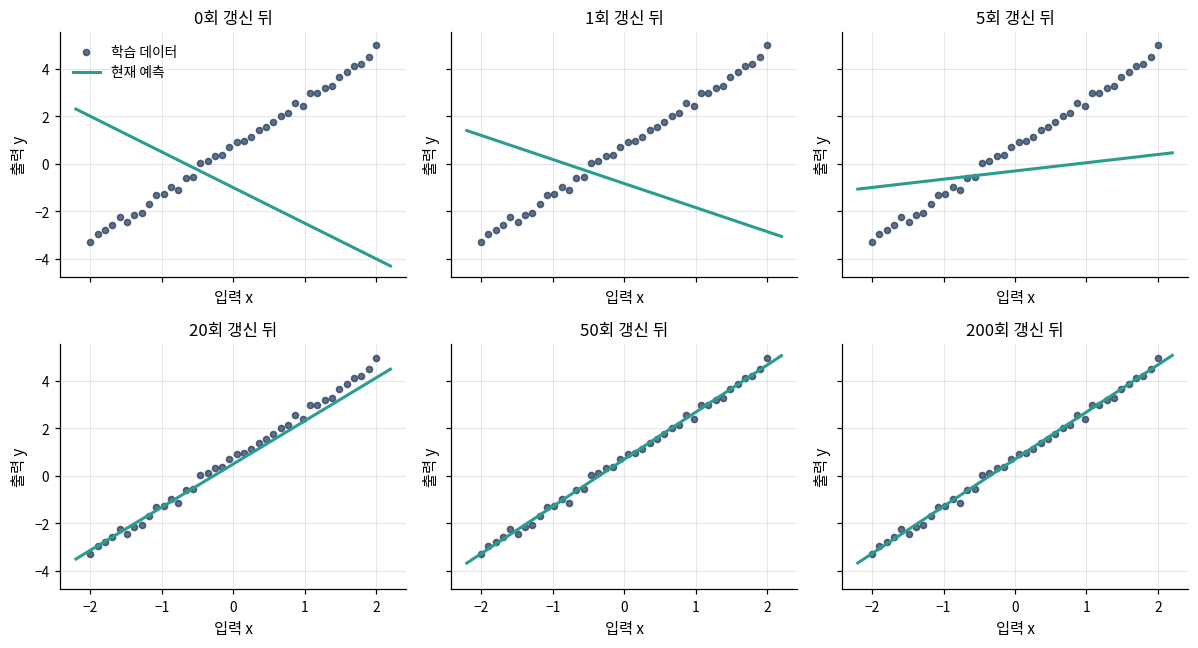

In [22]:
plot_fit_snapshots(X_train, Y_train, line_x, snapshot_predictions, snapshot_steps)

**이 실행에서 관찰할 것:** 초기에는 정답과 반대 방향이던 직선이 데이터에 맞추어 움직입니다.
잡음 때문에 손실의 최솟값은 양수이며, 경사하강으로 얻은 파라미터는 같은 데이터의 최소제곱 해에 가까워집니다.
이 비교는 구현한 학습 루프가 이 회귀 문제의 목적을 줄이는지 확인하는 검산입니다.

## 8. 손실 지형 위에서 갱신을 봅니다

가중치와 편향을 좌표로 두고 각 좌표의 손실을 계산하면, 모델이 내려가는 지형을 그릴 수 있습니다.
아래의 격자 손실 계산도 노트북 본문에서 수행합니다.

00번처럼 `meshgrid`로 후보 좌표를 펼칩니다. 이번에는 입력 좌표 대신 가중치와 편향의 후보를 놓습니다.
`ww`, `bb`의 행은 편향 후보, 열은 가중치 후보의 위치입니다.

| 배열 | shape | 각 축의 의미 |
|---|---|---|
| `ww`, `bb` | `(90, 90)` | 편향 후보, 가중치 후보 |
| `X_train[:, 0, None, None]` | `(40, 1, 1)` | 샘플, 편향 자리, 가중치 자리 |
| `ww[None]`, `bb[None]` | `(1, 90, 90)` | 샘플 자리, 편향 후보, 가중치 후보 |
| `grid_predictions` | `(40, 90, 90)` | 샘플, 편향 후보, 가중치 후보 |
| `loss_grid` | `(90, 90)` | 각 파라미터 후보 쌍의 손실 |

인덱싱의 `None`은 길이가 1인 축을 추가합니다. `X_train[:, 0]`으로 유일한 특성을 꺼내고
`None` 두 개로 뒤에 축을 붙이면 `(40, 1, 1)`이 됩니다. `ww[None]`은 앞에 축을 붙입니다.
브로드캐스팅하면 샘플 40개 각각을 후보 파라미터 $90 \times 90$개에 모두 적용할 수 있습니다.
`mean(..., axis=0)`은 샘플 축만 평균내므로 각 후보 쌍의 손실 하나씩이 남습니다.


In [23]:
ww, bb = np.meshgrid(np.linspace(-2.0, 3.0, 90), np.linspace(-1.5, 2.0, 90))
grid_predictions = X_train[:, 0, None, None] * ww[None] + bb[None]
loss_grid = 0.5 * np.mean((grid_predictions - Y_train[:, 0, None, None]) ** 2, axis=0)
parameter_path = np.array([[W[0, 0], b[0]] for W, b in zip(history["W"], history["b"])])
np.testing.assert_allclose(history["loss"][0],
                          0.5 * np.mean((X_train @ W_start + b_start - Y_train) ** 2))

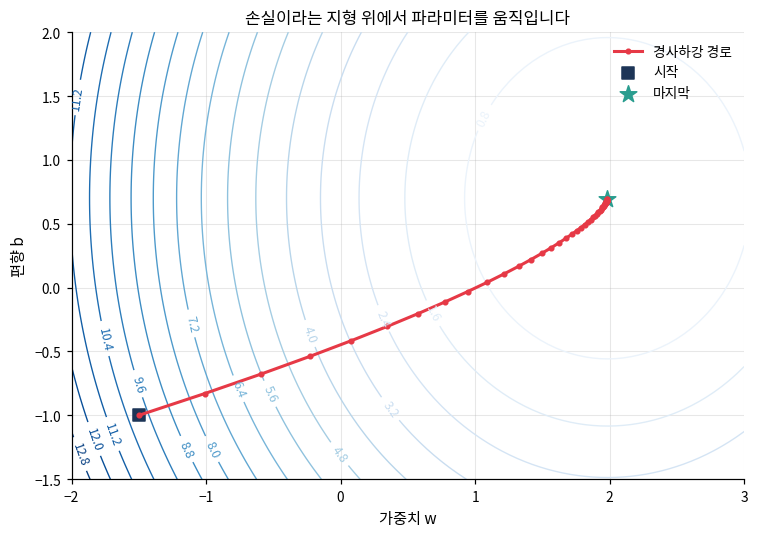

In [24]:
plot_loss_surface(ww, bb, loss_grid, parameter_path[:51])

### 학습률을 바꾸어 결과를 예상합니다

기울기가 정확하더라도 한 번에 너무 멀리 움직이면 손실이 커질 수 있습니다.
같은 시작점에서 작은 학습률, 이번 학습률, 큰 학습률을 비교합니다.
각 실행은 100회 갱신합니다.

In [25]:
learning_rate_runs = {}
for rate in [0.001, 0.1, 1.6]:
    _, _, trial = fit_linear(X_train, Y_train, W_start, b_start, learning_rate=rate, steps=100)
    learning_rate_runs[f"학습률 {rate:g}"] = trial["loss"]
    print(f"학습률 {rate:g}: {trial['loss'][0]:.6f} → {trial['loss'][-1]:.6f}")
assert learning_rate_runs["학습률 0.1"][-1] < learning_rate_runs["학습률 0.001"][-1]
assert learning_rate_runs["학습률 1.6"][-1] > learning_rate_runs["학습률 1.6"][0]

학습률 0.001: 9.961568 → 7.618282
학습률 0.1: 9.961568 → 0.008696
학습률 1.6: 9.961568 → 63905625558767566848.000000


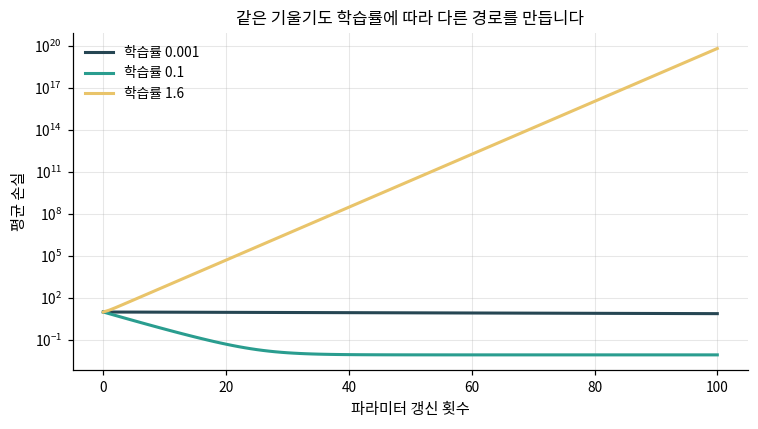

In [26]:
plot_learning_curves(learning_rate_runs)

기울기 검산과 학습률 실험은 다른 것을 확인합니다.
검산은 **현재 수식의 미분을 정확히 계산했는지**, 학습 실험은 **그 방향으로 정한 크기만큼 움직여 목적이 줄었는지**를 봅니다.
Momentum과 Adam을 공부할 때도 기울기 계산은 유지하고 갱신 규칙을 바꾸어 보겠습니다.

## 9. 직접 바꾸어 자신의 구현을 확인합니다

### 연습 A · 출력이 2개일 때 평균을 맞추기

아래 `(2, 2)` 예측에는 스칼라 오차가 4개 있습니다.
손실이 `0.5 * mean(residual ** 2)`라면 기울기는 각 잔차를 4로 나눈 값입니다.
아래 검사에 직접 작성한 `mse_backward` 함수를 전달해 보세요.

검사 예제 셀 아래에 새 Code 셀을 만들고 `my_mse_backward(residual)`을 직접 정의해 실행하세요. 그다음 셀에서 `check_mse_backward(my_mse_backward)`를 실행합니다.

In [27]:
def check_mse_backward(candidate):
    pred = np.array([[1., 0.], [2., 3.]])
    target = np.array([[0., 1.], [0., 1.]])
    loss, residual = mse_forward(pred, target)
    np.testing.assert_allclose(loss, 1.25)
    expected = np.array([[0.25, -0.25], [0.5, 0.5]])
    np.testing.assert_allclose(candidate(residual), expected)
    print("평균의 분모와 다중 출력 기울기가 손계산과 일치합니다.")

In [28]:
check_mse_backward(mse_backward)

평균의 분모와 다중 출력 기울기가 손계산과 일치합니다.


### 연습 B · 두 출력을 동시에 학습하기

같은 입력에서 $y_0=2x+0.7$, $y_1=-x+0.2$를 동시에 예측해 보겠습니다.
$W$는 `(1, 2)`, $b$는 `(2,)`가 됩니다.
기존 forward·backward·학습 함수가 그대로 동작해야 합니다.

먼저 필요한 배열 모양을 직접 적어 보고, 아래 완성 예제의 계수나 출력 개수를 바꾸어 보세요.

In [29]:
Y_two = np.column_stack([2.0 * X_train[:, 0] + 0.7, -X_train[:, 0] + 0.2])
W_two, b_two, history_two = fit_linear(
    X_train, Y_two, np.zeros((1, 2)), np.zeros(2), learning_rate=0.2, steps=200,
)
np.testing.assert_allclose(W_two, [[2., -1.]], atol=1e-7)
np.testing.assert_allclose(b_two, [0.7, 0.2], atol=1e-7)
print("두 출력의 가중치", W_two, "편향", b_two)
print(f"최종 손실 {history_two['loss'][-1]:.2e}")

두 출력의 가중치 [[ 2. -1.]] 편향 [0.7 0.2]
최종 손실 6.60e-20


### 연습 C · 설명을 가리고 연결해 보기

1. $J=\frac1{2M}\sum_j(\hat y_j-y_j)^2$에서 예측에 대한 미분을 다시 유도할 수 있나요?
2. `dW = X.T @ dZ`를 인덱스와 합으로 풀어 쓸 수 있나요?
3. 편향 기울기를 구할 때 샘플들의 기여를 더하는 이유를 설명할 수 있나요?
4. forward·손실·backward·update 네 부분을 직접 다시 작성할 수 있나요?
5. 손실이 커졌을 때 미분 오류와 학습률 문제를 각각 어떤 방법으로 점검할지 말할 수 있나요?

막힌 질문에 해당하는 절로 돌아가 작은 숫자로 한 번 더 계산합니다.
모양이나 계수를 바꾼 예제까지 검산하면, 코드를 읽는 이해와 직접 옮기는 이해를 함께 점검할 수 있습니다.

**다음 단원: 확률과 손실.** 확률·밀도·기댓값·우도를 코드로 확인하고,
가우스 오차에서 MSE, 범주형 확률에서 교차엔트로피가 나오는 과정을 연결합니다.
이후 MLP, optimizer, CNN, RNN·LSTM, attention, Transformer, GNN으로 확장합니다.

다음: [02 · 확률에서 손실 만들기](02_probability_and_losses.ipynb)